# PROJECT: BlaBlaCar Data Science Analysis
## Data Science for Business (IS525E)
### Ludovic Delot Bravo (20250308)



---
## Q1. Data: Import & Manipulation

This section focuses on loading the dataset, understanding its structure, and performing necessary cleaning and manipulation steps to prepare the data for further analysis and modeling.

### Q1.1 Importing Data

Here, we import the necessary libraries and load the dataset into a pandas DataFrame. This is the first step to get our data ready for analysis.

In [89]:
import pandas as pd # Import the pandas library, essential for data manipulation and analysis.
import matplotlib.pyplot as plt # Import matplotlib for creating static, interactive, and animated visualizations.

# Load the dataset from an Excel file into a pandas DataFrame.
# The file is expected to be located at '/content/BlaBla-Car_Data.xlsx' in the Colab environment.
df = pd.read_excel('/content/BlaBla-Car_Data.xlsx')

# Display the first 5 rows of the DataFrame.
# This function helps to quickly inspect the data structure and content after loading.
df.head()

,driver_id,offer_id,departure,arrival,trip_distance,offer_date,departure_date,price,nb_offers,photo,...,mean_price_depd,sd_price_depd,seats_in_car,seat_sold,Driver_first_name,Satisfaction_Livel,nb_evaluation,driver_age,driver_gender,Premium_Club
0,123956,427719,Lyon,Paris,425.0,5-Jan-14,1/12/2014 17:30,28,526.0,0,...,29.071247,2.567809,4,0,Francois,Excellent,0,25,0,0
1,81617,280534,Lyon,Paris,429.0,2-Jan-14,1/6/2014 14:40,30,526.0,0,...,28.862133,3.189145,0,0,Corinne,Good,24,31,1,0
2,198167,657605,Lyon,Paris,429.0,2-Jan-14,1/6/2014 15:10,31,526.0,1,...,28.862133,3.189145,0,0,Laura,Excellent,1,31,1,1
3,282817,946022,Lyon,Paris,429.0,2-Jan-14,1/6/2014 15:30,25,526.0,1,...,28.862133,3.189145,3,3,Philippe,VeryGood,3,31,0,1
4,29640,94886,Lyon,Paris,435.0,5-Jan-14,1/19/2014 9:00,25,526.0,1,...,29.364803,2.784098,7,4,Antoine,VeryGood,10,26,0,0


### Q1.2 Data Summary

This subsection provides an initial overview of the dataset, including column types, non-null counts, and basic statistical summaries for numerical columns. This helps in understanding the data's quality and characteristics.

In [90]:
# Display basic information about the DataFrame.
# .info() provides a concise summary, including the number of entries, number of columns,
# column names, their data types (dtypes), and the count of non-null values in each column.
# It also shows memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97625 entries, 0 to 97624
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   driver_id           97625 non-null  int64  
 1   offer_id            97625 non-null  int64  
 2   departure           97625 non-null  object 
 3   arrival             97625 non-null  object 
 4   trip_distance       97601 non-null  float64
 5   offer_date          97625 non-null  object 
 6   departure_date      97625 non-null  object 
 7   price               97625 non-null  int64  
 8   nb_offers           97603 non-null  float64
 9   photo               97625 non-null  int64  
 10  driver_status       97625 non-null  object 
 11  music               97625 non-null  int64  
 12  talk                97625 non-null  int64  
 13  pet                 97625 non-null  int64  
 14  smoking             97625 non-null  int64  
 15  manual_reservation  97625 non-null  int64  
 16  roun

In [91]:
# Display descriptive statistics for numerical columns in the DataFrame.
# .describe() provides insights such as count, mean, standard deviation, minimum, maximum,
# and quartile values (25th, 50th, 75th percentiles) for numerical data.
df.describe()

,driver_id,offer_id,trip_distance,price,nb_offers,photo,music,talk,pet,smoking,...,max_price_depd,min_price_depd,mean_price_depd,sd_price_depd,seats_in_car,seat_sold,nb_evaluation,driver_age,driver_gender,Premium_Club
count,97625.000000,9.762500e+04,97601.000000,97625.000000,97603.000000,97625.000000,97625.000000,97625.0,97625.000000,97625.000000,...,97625.000000,97625.000000,97625.000000,97613.000000,97625.000000,97625.000000,97625.000000,97625.000000,97625.000000,97625.000000
mean,183112.611268,6.122613e+05,467.667012,29.136020,767.564409,0.419001,0.571790,1.0,0.085163,0.058284,...,46.891431,17.492353,29.680794,3.299338,2.300026,1.159980,12.207877,34.633147,0.249209,0.249209
std,104032.508106,3.460801e+05,26.852776,3.538796,51.932390,0.493398,0.494822,0.0,0.279125,0.234281,...,18.193730,4.897133,0.679380,0.967332,1.833990,1.539941,22.740628,11.692740,0.432557,0.432557
min,10.000000,2.000000e+01,312.000000,1.000000,526.000000,0.000000,0.000000,1.0,0.000000,0.000000,...,23.000000,-1.000000,21.666666,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000
25%,91727.000000,3.207850e+05,462.000000,28.000000,761.000000,0.000000,0.000000,1.0,0.000000,0.000000,...,40.000000,15.000000,29.267822,2.752414,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000
50%,187454.000000,6.151750e+05,462.000000,30.000000,785.000000,0.000000,1.000000,1.0,0.000000,0.000000,...,42.000000,20.000000,29.720201,3.079294,3.000000,0.000000,4.000000,31.000000,0.000000,0.000000
75%,277383.000000,9.169910e+05,469.000000,30.000000,798.000000,1.000000,1.000000,1.0,0.000000,0.000000,...,46.000000,20.000000,30.103077,3.506759,4.000000,2.000000,13.000000,42.000000,0.000000,0.000000
max,354871.000000,1.192932e+06,1700.000000,251.000000,834.000000,1.000000,1.000000,1.0,1.000000,1.000000,...,251.000000,38.000000,38.000000,9.647118,18.000000,15.000000,357.000000,85.000000,1.000000,1.000000


In [92]:
# Print the shape of the DataFrame.
# .shape returns a tuple representing the dimensionality of the DataFrame (rows, columns).
print('Shape:', df.shape)
print()

# Print the count of missing values for each column.
# .isnull().sum() calculates the total number of NaN (Not a Number) values per column.
print('Missing values per column:')
print(df.isnull().sum())

Shape: (97625, 32)

Missing values per column:
driver_id              0
offer_id               0
departure              0
arrival                0
trip_distance         24
offer_date             0
departure_date         0
price                  0
nb_offers             22
photo                  0
driver_status          0
music                  0
talk                   0
pet                    0
smoking                0
manual_reservation     0
round_trip             0
car_rating             0
detour_time            0
page_view              0
max_price_depd         0
min_price_depd         0
mean_price_depd        0
sd_price_depd         12
seats_in_car           0
seat_sold              0
Driver_first_name      0
Satisfaction_Livel     5
nb_evaluation          0
driver_age             0
driver_gender          0
Premium_Club           0
dtype: int64


### Q1.3 Data Cleaning

This section addresses data quality issues such as missing values. It includes steps for normalizing missing value representations, checking null percentages, and implementing strategies to handle missing data through dropping or imputation.

#### Q1.3.1 Normalize Missing Values

This step ensures consistency in how missing values are represented. Specifically, it converts empty strings into proper NaN (Not a Number) values, which are better recognized by pandas for missing data handling.

In [93]:
# Replace empty strings ('') with None (which pandas treats as NaN).
# 'inplace=True' modifies the DataFrame directly without needing to assign the result back.
df.replace('', None, inplace=True)

#### Q1.3.2 Check Missing Values and Percentage of Nulls

After normalization, we re-evaluate the missing values to get an accurate picture of their distribution and proportion across the dataset. This helps in deciding appropriate imputation or dropping strategies.

In [94]:
# Calculate the count of null values for each column.
null_counts = df.isnull().sum()

# Calculate the percentage of null values for each column.
# .mean() gives the proportion of nulls, and multiplying by 100 converts it to a percentage.
null_pct = df.isnull().mean() * 100

# Create a DataFrame to display both null counts and their percentages side-by-side.
null_summary = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_summary)

                    Null Count    Null %
driver_id                    0  0.000000
offer_id                     0  0.000000
departure                    0  0.000000
arrival                      0  0.000000
trip_distance               24  0.024584
offer_date                   0  0.000000
departure_date               0  0.000000
price                        0  0.000000
nb_offers                   22  0.022535
photo                        0  0.000000
driver_status                0  0.000000
music                        0  0.000000
talk                         0  0.000000
pet                          0  0.000000
smoking                      0  0.000000
manual_reservation           0  0.000000
round_trip                   0  0.000000
car_rating                   0  0.000000
detour_time                  0  0.000000
page_view                    0  0.000000
max_price_depd               0  0.000000
min_price_depd               0  0.000000
mean_price_depd              0  0.000000
sd_price_depd   

#### Q1.3.3 Drop Columns with More Than 50% Missing Values

Columns with a very high percentage of missing values (e.g., over 50%) are often not useful for analysis or modeling. This step identifies and removes such columns to improve data quality and reduce dimensionality.

In [95]:
# Identify columns where the percentage of null values is greater than 50%.
# .index.tolist() extracts the column names into a list.
cols_to_drop = null_pct[null_pct > 50].index.tolist()
print('Columns dropped (>50% missing):', cols_to_drop)

# Drop the identified columns from the DataFrame.
# 'inplace=True' modifies the DataFrame directly.
df.drop(columns=cols_to_drop, inplace=True)

Columns dropped (>50% missing): []


#### Q1.3.4 Drop Rows for Columns with Less Than 5% Missing Values

For columns with a small number of missing values (e.g., less than 5%), it's often acceptable to remove the few rows that contain these missing entries. This approach avoids imputation, which could introduce bias, especially if the missingness mechanism is complex.

In [96]:
# Recalculate null percentages after potentially dropping columns in the previous step.
null_pct = df.isnull().mean() * 100

# Identify columns that have missing values (null_pct > 0) but less than 5% missing.
cols_low_null = null_pct[(null_pct > 0) & (null_pct < 5)].index.tolist()
print('Columns with <5% missing (dropping rows):', cols_low_null)

# If such columns exist, drop the rows where these specific columns have missing values.
# .dropna(subset=...) removes rows only if they have NaN in the specified columns.
if len(cols_low_null) > 0:
    df.dropna(subset=cols_low_null, inplace=True)

# Print the new shape of the DataFrame to show the effect of dropping rows.
print('Shape after dropping rows:', df.shape)

Columns with <5% missing (dropping rows): ['trip_distance', 'nb_offers', 'sd_price_depd', 'Satisfaction_Livel']
Shape after dropping rows: (97562, 32)


#### Q1.3.5 Fill Quantitative Variables with Mean by driver_status

For remaining missing values in numerical columns, imputation is performed. This strategy fills missing numerical data points with the mean value of that column, grouped by `driver_status`. This helps maintain the overall distribution characteristics within different driver segments.

In [97]:
# Get a list of all numerical columns in the DataFrame.
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Iterate through each numerical column.
for col in numeric_cols:
    # Check if the current column still has any missing values.
    if df[col].isnull().sum() > 0:
        # Fill missing values with the mean of the column, calculated separately for each 'driver_status' group.
        # .transform() ensures that the result is broadcast back to the original DataFrame's shape.
        df[col] = df.groupby('driver_status')[col].transform(lambda x: x.fillna(x.mean()))
        print(f'Filled {col} with mean by driver_status')

# After filling, check if there are any remaining null values in numerical columns.
print('Remaining nulls in numeric columns:', df[numeric_cols].isnull().sum().sum())

Remaining nulls in numeric columns: 0


#### Q1.3.6 Fill Categorical Variables with Mode

For categorical variables with missing values, a common imputation strategy is to replace them with the mode (the most frequent value). This maintains the common category without introducing new, potentially unrealistic, categories.

In [98]:
# Get a list of all categorical columns (object type) in the DataFrame.
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through each categorical column.
for col in cat_cols:
    # Check if the current column has any missing values.
    if df[col].isnull().sum() > 0:
        # Calculate the mode (most frequent value) of the column. .mode()[0] handles cases with multiple modes.
        mode_val = df[col].mode()[0]
        # Fill missing values in the column with its mode.
        df[col].fillna(mode_val, inplace=True)
        print(f'Filled {col} with mode: {mode_val}')

# Final check: Print the total number of remaining null values in the entire DataFrame.
# This confirms that all missing values have been handled.
print()
print('Total remaining nulls:', df.isnull().sum().sum())


Total remaining nulls: 0


### Q1.4 Data Manipulation

This section demonstrates various techniques to manipulate and extract specific information from the DataFrame, showcasing pandas' capabilities for data querying and aggregation.

#### Q1.4.1 Find the Driver Name with the Maximum trip_distance

This task involves identifying the driver associated with the longest recorded trip distance in the dataset. It highlights how to find extreme values and retrieve associated information.

In [99]:
# Find the index of the row with the maximum 'trip_distance'.
# .idxmax() returns the index of the first occurrence of the maximum value.
max_idx = df['trip_distance'].idxmax()

# Use the identified index to retrieve the 'Driver_first_name' from that specific row.
print('Driver with max trip_distance:', df.loc[max_idx, 'Driver_first_name'])

Driver with max trip_distance: Claude


#### Q1.4.2 Print the Minimum page_view and nb_offers by driver_status

This analysis groups the data by `driver_status` and then finds the minimum values for `page_view` and `nb_offers` within each status group. This helps in understanding the baseline activity metrics for different driver statuses.

In [100]:
# Group the DataFrame by 'driver_status' and calculate the minimum 'page_view' and 'nb_offers' for each group.
# .min() returns the minimum value for the specified columns within each group.
min_by_status = df.groupby('driver_status')[['page_view', 'nb_offers']].min()
print(min_by_status)

               page_view  nb_offers
driver_status                      
S1                     0      526.0
S2                     0      526.0
S3                     0      526.0
S4                     0      526.0
S5                     0      526.0


#### Q1.4.3 Use a for Loop to Print the Driver Name with the Maximum detour_time by driver_status

This task iterates through each unique `driver_status` to find the driver who experienced the maximum `detour_time` within that specific status group. It demonstrates looping through groups and extracting specific information.

In [101]:
# Iterate over each unique 'driver_status' present in the DataFrame.
for status in df['driver_status'].unique():
    # Create a subset of the DataFrame containing only rows for the current 'driver_status'.
    subset = df[df['driver_status'] == status]
    # Find the index of the row within this subset that has the maximum 'detour_time'.
    max_idx = subset['detour_time'].idxmax()
    # Retrieve the 'Driver_first_name' using the index from the subset.
    driver_name = subset.loc[max_idx, 'Driver_first_name']
    # Print the result for the current driver status.
    print(f'driver_status: {status} -> Driver with max detour_time: {driver_name}')

driver_status: S2 -> Driver with max detour_time: Julien
driver_status: S5 -> Driver with max detour_time: Jean-Baptiste
driver_status: S3 -> Driver with max detour_time: Armand
driver_status: S4 -> Driver with max detour_time: Mustapha
driver_status: S1 -> Driver with max detour_time: Marcel


#### Q1.4.4 Define a Function with driver_id as Argument

This task defines a reusable function that takes a `driver_id` as input and returns aggregated information about that specific driver, such as their first name, age, average trip distance, and average price. This showcases functional programming for data retrieval.

In [102]:
# Define a function named `get_driver_info` that takes one argument: `driver_id`.
def get_driver_info(driver_id):
    # Filter the DataFrame to get all entries for the specified driver_id.
    driver_df = df[df['driver_id'] == driver_id]
    # Extract the first name of the driver. .iloc[0] is used to get the first entry in case a driver has multiple records.
    first_name = driver_df['Driver_first_name'].iloc[0]
    # Extract the driver's age.
    age = driver_df['driver_age'].iloc[0]
    # Calculate the average trip distance for this driver across all their trips.
    avg_distance = driver_df['trip_distance'].mean()
    # Calculate the average price for this driver's trips.
    avg_price = driver_df['price'].mean()
    # Return the collected information as a tuple.
    return (first_name, age, avg_distance, avg_price)

# Call the function with a specific driver_id (201315) to retrieve their information.
result = get_driver_info(201315)
# Print the results, accessing elements of the returned tuple by their index.
print('Driver First Name:', result[0])
print('Driver Age:', result[1])
print('Average trip_distance:', result[2])
print('Average Price:', result[3])

Driver First Name: Laurent
Driver Age: 47
Average trip_distance: 534.6
Average Price: 32.0


---
## Q2. Data Visualization & Data Analysis

This section explores the dataset through visual representations and advanced analytical techniques. It aims to uncover patterns, relationships, and key insights related to driver behavior, trip details, and customer satisfaction levels.

### Q2.1 Data Visualization

Visualizations are crucial for understanding data distributions, trends, and comparisons between different groups. This subsection generates various charts to illustrate key aspects of the BlaBlaCar dataset.

#### Q2.1.1 Bar Chart of the Average min_price_depd and max_price_depd by Satisfaction_Livel

This visualization compares the average minimum and maximum prices offered for departures, categorized by the driver's `Satisfaction_Livel`. It helps in understanding how driver satisfaction might correlate with pricing strategies.

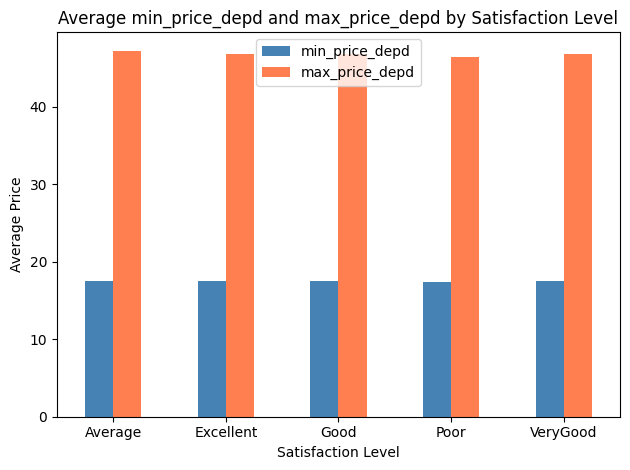

In [103]:
# Group the DataFrame by 'Satisfaction_Livel' and calculate the mean of 'min_price_depd' and 'max_price_depd' for each group.
avg_prices = df.groupby('Satisfaction_Livel')[['min_price_depd', 'max_price_depd']].mean()

# Create a bar chart using the calculated average prices.
# 'kind='bar'' specifies a bar plot.
# 'color' sets the colors for the bars.
avg_prices.plot(kind='bar', color=['steelblue', 'coral'])
# Set the title of the plot.
plt.title('Average min_price_depd and max_price_depd by Satisfaction Level')
# Set the label for the x-axis.
plt.xlabel('Satisfaction Level')
# Set the label for the y-axis.
plt.ylabel('Average Price')
# Display a legend to differentiate between min and max prices.
plt.legend(['min_price_depd', 'max_price_depd'])
# Rotate x-axis labels to prevent overlap, setting rotation to 0 for horizontal labels.
plt.xticks(rotation=0)
# Adjust plot to ensure all elements fit without overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

#### Q2.1.2 Pie Chart of the Maximum nb_evaluation by driver_status

This pie chart visualizes the distribution of the maximum number of evaluations received by drivers, segmented by their `driver_status`. It offers a proportional view of which driver status categories achieve the highest evaluation counts.

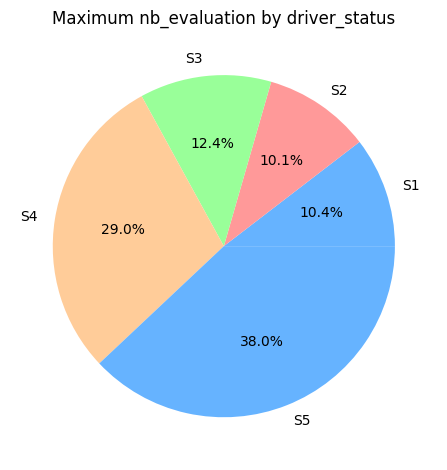

In [104]:
# Group the DataFrame by 'driver_status' and find the maximum 'nb_evaluation' for each status.
# .max() returns the maximum value for 'nb_evaluation' within each group.
max_eval = df.groupby('driver_status')['nb_evaluation'].max()

# Create a pie chart from the 'max_eval' Series.
# 'autopct='%1.1f%%'' formats the percentage displayed on each slice.
# 'colors' sets the colors for the pie slices.
max_eval.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'])
# Set the title of the plot.
plt.title('Maximum nb_evaluation by driver_status')
# Remove the default y-axis label for cleaner appearance in pie charts.
plt.ylabel('')
# Adjust plot to ensure all elements fit without overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

#### Q2.1.3 Histogram of driver_age with Five Age Ranges

This histogram illustrates the distribution of driver ages within predefined age bins. It helps in understanding the demographic spread of drivers, which can be useful for targeted marketing or service adjustments.

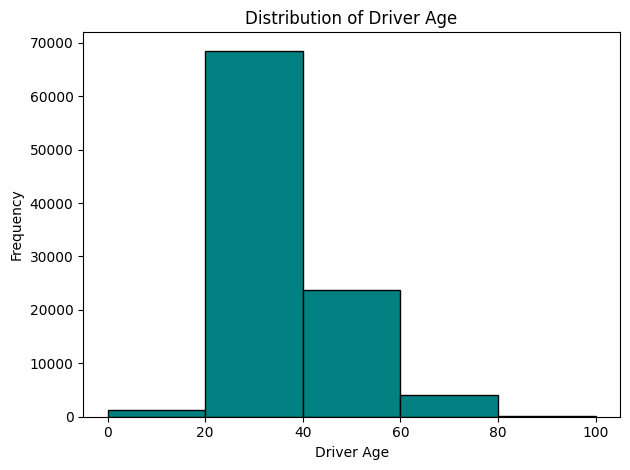

In [105]:
# Define the bins (age ranges) for the histogram.
# These bins divide the age data into specified intervals.
bins = [0, 20, 40, 60, 80, 100]

# Create a histogram of the 'driver_age' column.
# 'bins' specifies the age intervals.
# 'color' sets the fill color of the bars.
# 'edgecolor' sets the border color of the bars.
plt.hist(df['driver_age'], bins=bins, color='teal', edgecolor='black')
# Set the title of the plot.
plt.title('Distribution of Driver Age')
# Set the label for the x-axis.
plt.xlabel('Driver Age')
# Set the label for the y-axis.
plt.ylabel('Frequency')
# Set the x-axis tick marks to correspond to the bin edges for clarity.
plt.xticks(bins)
# Adjust plot to ensure all elements fit without overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

#### Q2.1.4 Lyon Departure Analysis: Average detour_time and page_view by Satisfaction_Livel

This bar chart focuses on trips departing from Lyon, analyzing the average `detour_time` and `page_view` metrics, grouped by the `Satisfaction_Livel` of the drivers. This granular analysis can reveal specific regional insights into driver experience and platform engagement.

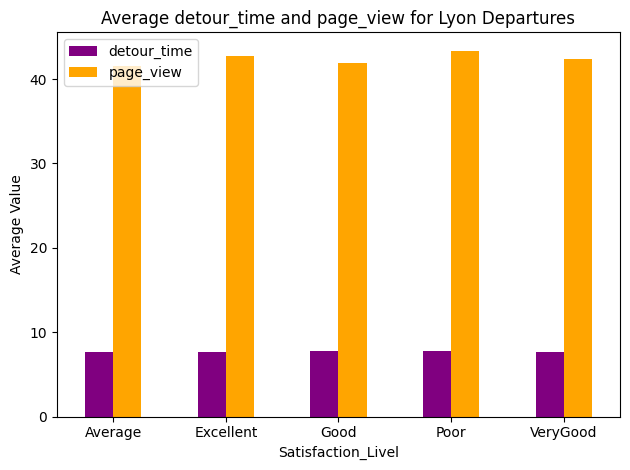

In [106]:
# Filter the DataFrame to include only trips where the 'departure' city is 'Lyon'.
lyon_df = df[df['departure'] == 'Lyon']

# Group the 'lyon_df' by 'Satisfaction_Livel' and calculate the mean of 'detour_time' and 'page_view' for each level.
lyon_avg = lyon_df.groupby('Satisfaction_Livel')[['detour_time', 'page_view']].mean()

# Create a bar chart from the aggregated data.
# 'kind='bar'' specifies a bar plot.
# 'color' sets the colors for the bars.
lyon_avg.plot(kind='bar', color=['purple', 'orange'])
# Set the title of the plot.
plt.title('Average detour_time and page_view for Lyon Departures')
# Set the label for the x-axis.
plt.xlabel('Satisfaction_Livel')
# Set the label for the y-axis.
plt.ylabel('Average Value')
# Display a legend to differentiate between 'detour_time' and 'page_view'.
plt.legend(['detour_time', 'page_view'])
# Rotate x-axis labels to prevent overlap, setting rotation to 0 for horizontal labels.
plt.xticks(rotation=0)
# Adjust plot to ensure all elements fit without overlapping.
plt.tight_layout()
# Display the plot.
plt.show()

### Q2.2 Data Analysis

This section delves into specific analytical calculations to derive meaningful metrics like "Business Index" and "Confort Index" for drivers. These custom metrics help in identifying top-performing or most comfortable drivers based on defined criteria.

#### Q2.2.1 Top 10 Maximum Business Index Drivers

The "Business Index" is defined as the product of total trip distance and average price for each driver. This metric helps identify drivers who generate the most business value through long-distance and well-priced trips. This section calculates and displays the top 10 drivers by this index.

In [107]:
# Calculate the Business_Index for each driver.
# First, group the DataFrame by 'driver_id' and aggregate two metrics:
# - 'total_distance': sum of 'trip_distance' for each driver.
# - 'avg_price': mean of 'price' for each driver.
# - 'Driver_name': get the first occurrence of 'Driver_first_name' for each driver_id.
business = df.groupby('driver_id').agg(
    total_distance=('trip_distance', 'sum'),
    avg_price=('price', 'mean'),
    Driver_name=('Driver_first_name', 'first') # Get the first name, assuming it's consistent per driver_id
).reset_index() # Reset the index to turn 'driver_id' back into a column.

# Calculate the 'Business_Index' as the product of 'total_distance' and 'avg_price'.
business['Business_Index'] = business['total_distance'] * business['avg_price']

# Sort the 'business' DataFrame by 'Business_Index' in descending order and select the top 10 drivers.
top10_business = business.sort_values('Business_Index', ascending=False).head(10)
# Print the results, showing 'driver_id', 'Driver_name', and their 'Business_Index'.
print('Top 10 Max Business Index Drivers:')
print(top10_business[['driver_id', 'Driver_name', 'Business_Index']])

Top 10 Max Business Index Drivers:
       driver_id Driver_name  Business_Index
47208     305080     Samidil    1.189650e+06
44016     284076      Pierre    1.027223e+06
29858     191564       Karim    9.710910e+05
47712     308156      Saphir    9.600360e+05
38380     253409     Mohamed    9.569106e+05
54755     349812       Yazid    9.118216e+05
24715     155716        Isma    8.943259e+05
45555     293799        Remy    8.280747e+05
29185     188225      Julien    8.218305e+05
21779     137549      Gilles    7.636570e+05


#### Q2.2.2 Top 10 Maximum Confort Index Drivers

The "Confort Index" is calculated as `(car_rating + detour_time + music - smoking)` per driver. This custom metric aims to quantify driver comfort for passengers, considering factors like car quality, willingness to detour, musical preference, and smoking habits. This section identifies and lists the top 10 drivers with the highest comfort index.

In [108]:
# Calculate the Confort_Index for each driver.
# First, group the DataFrame by 'driver_id' and aggregate relevant metrics:
# - 'car_rating': mean of 'car_rating' for each driver.
# - 'detour_time': mean of 'detour_time' for each driver.
# - 'music': mean of 'music' (binary indicator) for each driver.
# - 'smoking': mean of 'smoking' (binary indicator) for each driver.
# - 'Driver_name': get the first occurrence of 'Driver_first_name'.
confort = df.groupby('driver_id').agg(
    car_rating=('car_rating', 'mean'),
    detour_time=('detour_time', 'mean'),
    music=('music', 'mean'),
    smoking=('smoking', 'mean'),
    Driver_name=('Driver_first_name', 'first')
).reset_index() # Reset the index to turn 'driver_id' back into a column.

# Calculate the 'Confort_Index' using the specified formula.
confort['Confort_Index'] = confort['car_rating'] + confort['detour_time'] + confort['music'] - confort['smoking']

# Sort the 'confort' DataFrame by 'Confort_Index' in descending order and select the top 10 drivers.
top10_confort = confort.sort_values('Confort_Index', ascending=False).head(10)
# Print the results, showing 'driver_id', 'Driver_name', and their 'Confort_Index'.
print('Top 10 Max Confort Index Drivers:')
print(top10_confort[['driver_id', 'Driver_name', 'Confort_Index']])

Top 10 Max Confort Index Drivers:
       driver_id      Driver_name  Confort_Index
54986     351008            Yohan           35.0
4371       29700          Antoine           35.0
17864     114154         Fabrizio           35.0
19934     125088  Francois-Xavier           35.0
12263      77369          Clement           35.0
12286      77560          Clement           35.0
23           170            Abbee           35.0
44188     284657           Pierre           35.0
45010     290352          Raphael           35.0
44950     289970             Rami           35.0


### Q2.3 BlaBlaCar Premium Club Prediction

This section focuses on building a machine learning model to predict whether a driver will subscribe to the Premium Club. This is framed as a binary classification problem using Logistic Regression, a fundamental algorithm for such tasks.

#### Q2.3.1 Define the Prediction Objective

The primary goal of this task is to predict whether a BlaBlaCar user will subscribe to the Premium Club. This is a **binary classification** problem, meaning the model will output one of two possible classes: subscribed (1) or not subscribed (0).

For this prediction task, we will utilize a **Logistic Regression** model, which is well-suited for binary classification and provides probabilistic outputs.

#### Q2.3.2 Prepare the Data

This crucial step involves setting up the data for the machine learning model. It includes importing necessary libraries, defining target and ID columns, splitting the data into features (X) and target (y), handling missing values, and dividing the dataset into training and testing sets.

In [109]:
from sklearn.model_selection import train_test_split # Used to split data into training and testing sets.
from sklearn.linear_model import LogisticRegression # The classification model we will use.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Metrics for model evaluation.

# Check and print the list of all column names in the DataFrame.
# This helps in identifying potential features and the target variable ('Premium_Club').
print(df.columns.tolist())

['driver_id', 'offer_id', 'departure', 'arrival', 'trip_distance', 'offer_date', 'departure_date', 'price', 'nb_offers', 'photo', 'driver_status', 'music', 'talk', 'pet', 'smoking', 'manual_reservation', 'round_trip', 'car_rating', 'detour_time', 'page_view', 'max_price_depd', 'min_price_depd', 'mean_price_depd', 'sd_price_depd', 'seats_in_car', 'seat_sold', 'Driver_first_name', 'Satisfaction_Livel', 'nb_evaluation', 'driver_age', 'driver_gender', 'Premium_Club']


In [110]:
import numpy as np # Used for numerical operations, especially with arrays.
from sklearn.model_selection import train_test_split # Function to split datasets into training and testing subsets.
from sklearn.linear_model import LogisticRegression # The classifier model for binary prediction.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Functions to evaluate model performance.
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling.

# Define the target variable's column name.
TARGET = "Premium_Club"
# Define columns that are unique identifiers and should not be used as features.
ID_COLUMNS = ["driver_id", "offer_id"]
# Define the proportion of the dataset to be used for testing (20%).
TEST_SIZE = 0.20
# Define a random state for reproducibility of the data split and model training.
RANDOM_STATE = 42

# --- Target Variable Validation and Preparation ---
# Check if the TARGET column exists in the DataFrame.
if TARGET not in df.columns:
    raise ValueError(f"La columna target '{TARGET}' no existe en el DataFrame.")

# Ensure the target variable is binary (0 or 1).
# If it contains other values but only two unique values, it attempts to convert them to 0/1.
if not df[TARGET].isin([0, 1]).all():
    if df[TARGET].nunique() == 2:
        unique_vals = sorted(df[TARGET].dropna().unique().tolist())
        if len(unique_vals) == 2:
            val0, val1 = unique_vals[0], unique_vals[1]
            df[TARGET] = df[TARGET].replace({val0: 0, val1: 1})
            print(f"Converted target from {val0}/{val1} to 0/1.")
    else:
        raise ValueError(f"El target debe ser binario con valores 0 y 1. Valores encontrados: {df[TARGET].unique()}")

# Convert the target column to integer type, ensuring it's treated as binary.
df[TARGET] = df[TARGET].astype(int)

# --- Feature (X) and Target (y) Separation ---
# Create a list of columns to be dropped from the features (X), including the target and ID columns.
drop_cols = [TARGET] + [col for col in ID_COLUMNS if col in df.columns]
# X contains all features (columns) excluding the target and ID columns.
X = df.drop(columns=drop_cols, errors="ignore")
# y contains only the target variable ('Premium_Club').
y = df[TARGET]

# --- Simplification: Keep only numeric features and handle missing values directly ---
# Select only numerical columns from X to be used as features.
numeric_X = X.select_dtypes(include=np.number).copy()

# Iterate through each numerical column to fill any remaining missing values.
for col in numeric_X.columns:
    if numeric_X[col].isnull().any(): # Check if the column has any NaN values.
        # Fill missing values with the mean of that column. This is a simple imputation strategy.
        numeric_X[col] = numeric_X[col].fillna(numeric_X[col].mean())

# Update X to contain only the cleaned numerical features.
X = numeric_X

# Print the shape of the features DataFrame and the distribution of the target variable.
print('Features shape after simplification:', X.shape)
print('Target distribution:\n', y.value_counts())

# --- Stratified Data Splitting ---
# Split the data into training and testing sets.
# X_train: Features for training. It will contain the features that the model will learn from.
# y_train: Target variable for training. It contains the correct answers for X_train.
# X_test: Features for testing. These are unseen data used to evaluate the model.
# y_test: Target variable for testing. These are the correct answers for X_test.
# test_size: The proportion of the dataset to allocate for the test set (e.g., 0.20 means 20% for testing).
# random_state: An integer to ensure the data split is the same every time the code is run, making results reproducible.
# stratify=y: Ensures that the proportion of target classes (Premium_Club 0s and 1s) is approximately the same in both training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# --- Feature Scaling ---
# Initialize the StandardScaler.
# StandardScaler transforms features by subtracting the mean and dividing by the standard deviation,
# so that the resulting distribution has a mean of 0 and a standard deviation of 1.
# This is important for optimization algorithms like those used by Logistic Regression to converge faster.
scaler = StandardScaler()
# Fit the scaler on the training data (X_train) and then transform X_train.
# 'fit' calculates the mean and standard deviation from X_train.
# 'transform' applies these calculated values to scale X_train.
X_train_scaled = scaler.fit_transform(X_train)
# Transform the test data (X_test) using the scaler fitted on the training data.
# It is crucial to use the same scaling parameters (mean and std dev) learned from the training set
# to avoid data leakage from the test set into the training process.
X_test_scaled = scaler.transform(X_test)

# Update X_train and X_test to be the scaled versions for subsequent model training.
X_train = X_train_scaled
X_test = X_test_scaled

print('Data preparation complete. Numeric features are imputed and scaled.')

Features shape after simplification: (97562, 22)
Target distribution:
 Premium_Club
0    73256
1    24306
Name: count, dtype: int64
Data preparation complete. Numeric features are imputed and scaled.


#### Q2.3.3 Split the Data into Training and Testing Sets

#### Q2.3.4 Train a Basic Machine Learning Model

In this section, we instantiate and train a Logistic Regression model. This model is chosen for its simplicity and effectiveness in binary classification tasks. The `class_weight='balanced'` parameter is particularly useful for handling imbalanced datasets, where one class is much more frequent than the other, by adjusting weights inversely proportional to class frequencies.

#### Q2.3.3 Split the Data into Training and Testing Sets

This step is crucial for machine learning model development. The dataset is divided into two parts: a training set (used to train the model) and a testing set (used to evaluate the model's performance on unseen data). The split is stratified to ensure that the class distribution of the target variable is maintained in both sets.

*Note: The actual data splitting logic has been integrated into the previous 'Prepare the Data' cell for a more streamlined and simplified flow.*

In [111]:
# --- Simplification: Train Logistic Regression directly ---
# Initialize the Logistic Regression model.
# max_iter=1000: Sets the maximum number of iterations for the solver to converge.
#                Reduced from 5000 as the data is now scaled, which typically helps convergence occur faster.
# random_state=RANDOM_STATE: Ensures reproducibility of the model training.
# class_weight='balanced': Automatically adjusts weights inversely proportional to class frequencies.
#                         This is beneficial for imbalanced datasets (where one class has significantly more samples than others)
#                         to prevent the model from being biased towards the majority class.
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')

# Train the model using the scaled training data.
# X_train: The scaled feature matrix for training, where the model learns the relationships between features and the target.
# y_train: The target variable (Premium_Club status) for the training data, providing the correct labels for the model to learn from.
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


#### Q2.3.5 Evaluate the Model

After training, the model's performance is evaluated on the unseen test dataset. This step involves making predictions and then computing several key metrics such as accuracy, confusion matrix, and a classification report to understand how well the model performs in classifying Premium Club subscribers.

In [112]:
# Make predictions on the test set (X_test) using the trained model.
# model.predict(X_test) applies the learned model to the unseen test features (X_test)
# and outputs the predicted class labels (0 or 1) for Premium Club subscription.
y_pred = model.predict(X_test)

# Print the overall accuracy of the model.
# accuracy_score compares the true labels (y_test) with the predicted labels (y_pred).
# It calculates the proportion of correctly classified samples.
# round(..., 4) formats the output to 4 decimal places for readability.
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))

# Print the confusion matrix.
# The confusion_matrix provides a detailed breakdown of correct and incorrect predictions for each class.
# It is a table showing the number of True Positives, True Negatives, False Positives, and False Negatives.
# - True Positives (TP): Correctly predicted positive cases.
# - True Negatives (TN): Correctly predicted negative cases.
# - False Positives (FP): Incorrectly predicted positive cases (Type I error).
# - False Negatives (FN): Incorrectly predicted negative cases (Type II error).
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

# Print the classification report.
# This report provides more detailed metrics for each class:
# - Precision: The proportion of positive identifications that were actually correct (TP / (TP + FP)).
# - Recall (Sensitivity): The proportion of actual positives that were correctly identified (TP / (TP + FN)).
# - F1-score: The harmonic mean of precision and recall, providing a balance between the two.
# - Support: The number of actual occurrences of each class in the specified dataset.
# It also includes macro average (unweighted mean) and weighted average (weighted by support) of these metrics.
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.6852

Confusion Matrix:
 [[11592  3060]
 [ 3082  1779]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79     14652
           1       0.37      0.37      0.37      4861

    accuracy                           0.69     19513
   macro avg       0.58      0.58      0.58     19513
weighted avg       0.68      0.69      0.68     19513

